# 🎓 Complete Machine Learning Pipeline
### Data Cleaning → Visualisation → Feature Engineering → Model Training → Evaluation

---

> **Dataset:** Pima Indians Diabetes Dataset (768 patients)  
> **Goal:** Predict whether a patient has diabetes based on health indicators  
> **Model:** Linear Regression  

---

## 📋 Table of Contents

| Step | Topic |
|------|-------|
| 1 | Import Libraries |
| 2 | Load and Explore Data |
| 3 | Clean the Data |
| 4 | Visualise the Data |
| 5 | What is Scikit-learn? |
| 6 | Encode Categorical Columns |
| 7 | Feature Scaling |
| 8 | Train-Test Split |
| 9 | What is Linear Regression? |
| 10 | Train the Model |
| 11 | Evaluate the Model |
| 12 | Visualise Predictions |
| 13 | Predict New Patients |
| 14 | Summary + Exercises |

---
# Step 1 — Import Libraries
---
We import all the libraries we need at the very top.

**Why at the top?** So anyone reading the notebook immediately knows what tools we are using.

In [1]:
# ── Data Manipulation ────────────────────────────────────────
import pandas as pd        # for loading and cleaning data
import numpy as np         # for math and array operations

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt   # base charting library
import seaborn as sns             # statistical charts on top of matplotlib

# ── Machine Learning (Scikit-learn) ───────────────────────────
from sklearn.model_selection import train_test_split    # split data
from sklearn.linear_model   import LinearRegression  
from sklearn.linear_model   import Ridge                # for Ridge regression
from sklearn.linear_model   import Lasso 
               # for Lasso regression
from sklearn.preprocessing  import PolynomialFeatures     # our model
from sklearn.metrics        import (mean_absolute_error,
                                    mean_squared_error,
                                    r2_score)            # evaluation
from sklearn.preprocessing  import StandardScaler       # feature scaling

# ── Settings ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
# Step 2 — Load and Explore the Data
---

**Two key terms:**
- **Feature (X)** = inputs to the model — health indicators (Glucose, BMI, Age, etc.)
- **Target (y)** = what we want to predict — `Outcome` (0 = Not Diabetic, 1 = Diabetic)

Our job is to teach the model: *given these health readings, predict the diabetes outcome.*

In [2]:
# Load the CSV file
# Make sure diabetes.csv is in the same folder as this notebook
df = pd.read_csv('diabetes.csv')

print(f'Loaded: {df.shape[0]} patients, {df.shape[1]} columns')

Loaded: 768 patients, 9 columns


In [3]:
# See the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Overview: column names, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Statistical summary — check min/max for impossible values
# IMPORTANT: Glucose, BloodPressure, SkinThickness, Insulin, BMI
# cannot be 0 in real life — these are actually MISSING values!
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
# Count official NaN missing values
print('Official NaN missing values:')
print(df.isnull().sum())

print('\n⚠️  But zeros in medical columns are actually missing values!')

# Count zeros in columns where 0 is medically impossible
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nZero counts (hidden missing values):')
for col in medical_cols:
    print(f'  {col}: {(df[col] == 0).sum()} zeros')

Official NaN missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

⚠️  But zeros in medical columns are actually missing values!

Zero counts (hidden missing values):
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros


In [7]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Check target balance
print('\nTarget variable distribution:')
print(df['Outcome'].value_counts())
print(f'\n  0 = Not Diabetic: {(df["Outcome"]==0).sum()} patients ({(df["Outcome"]==0).mean()*100:.1f}%)')
print(f'  1 = Diabetic    : {(df["Outcome"]==1).sum()} patients ({(df["Outcome"]==1).mean()*100:.1f}%)')

Duplicate rows: 0

Target variable distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

  0 = Not Diabetic: 500 patients (65.1%)
  1 = Diabetic    : 268 patients (34.9%)


### 📝 What We Found

| Column | Issue |
|--------|-------|
| `Glucose` | 5 zeros = hidden missing values |
| `BloodPressure` | 35 zeros = hidden missing values |
| `SkinThickness` | 227 zeros = hidden missing values |
| `Insulin` | 374 zeros = hidden missing values |
| `BMI` | 11 zeros = hidden missing values |
| Duplicate rows | None |
| Target distribution | 65% Not Diabetic, 35% Diabetic |

---
# Step 3 — Clean the Data
---

The main issue: zeros in medical columns are NOT real zeros — they represent missing data.

**Strategy:** Replace all zeros in medical columns with the **median** of that column.
We use median (not mean) because it is less affected by extreme outlier values.

In [8]:
# Always work on a copy — never modify the original
df_clean = df.copy()

# Replace 0s with NaN first, then fill with median
# Columns where 0 is medically impossible
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in medical_cols:
    # Step 1: Replace 0 with NaN
    df_clean[col] = df_clean[col].replace(0, np.nan)
    # Step 2: Fill NaN with median of that column
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('✅ Zeros replaced with median values')
print('Missing values remaining:', df_clean.isnull().sum().sum())
print('Shape:', df_clean.shape)

✅ Zeros replaced with median values
Missing values remaining: 0
Shape: (768, 9)


In [9]:
# Verify the fix — minimum values should no longer be 0
print('Minimum values after cleaning:')
print(df_clean[medical_cols].min().round(2))

Minimum values after cleaning:
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


---
# Step 4 — Visualise the Data
---

**This step is not optional.** Always visualise before building any model.

Visualisation tells us:
- Which features are most related to diabetes outcome
- The shape of distributions (normal? skewed?)
- Any patterns the model should pick up

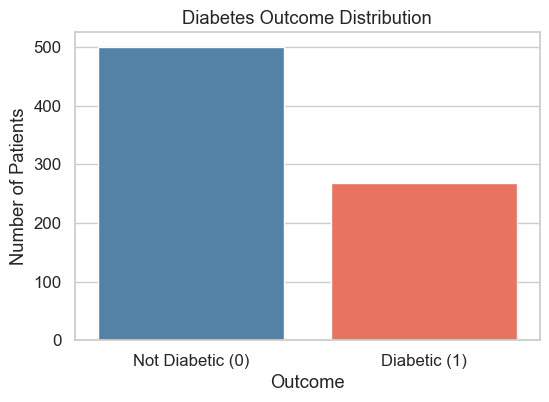

65% Not Diabetic vs 35% Diabetic — slightly imbalanced dataset


In [10]:
# Chart 1 — Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Outcome', palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Not Diabetic (0)', 'Diabetic (1)'])
plt.title('Diabetes Outcome Distribution')
plt.ylabel('Number of Patients')
plt.show()
print('65% Not Diabetic vs 35% Diabetic — slightly imbalanced dataset')

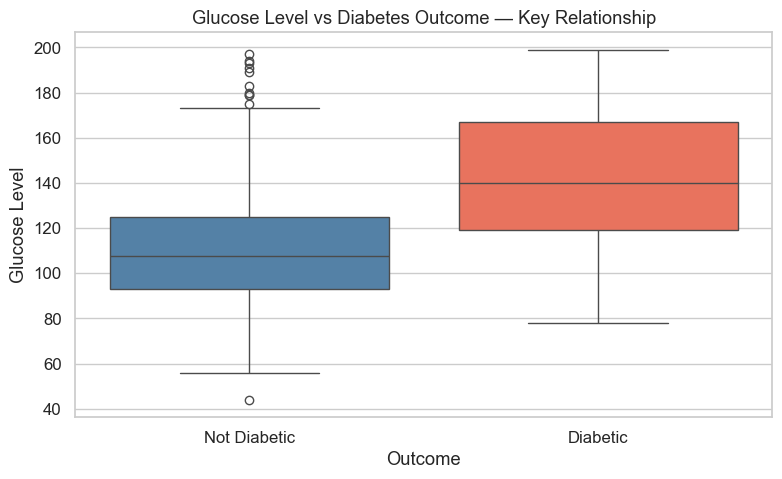

In [11]:
# Chart 2 — The Most Important Relationship: Glucose vs Outcome
# Glucose is typically the strongest predictor of diabetes
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Outcome', y='Glucose', palette=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Not Diabetic', 'Diabetic'])
plt.title('Glucose Level vs Diabetes Outcome — Key Relationship')
plt.xlabel('Outcome')
plt.ylabel('Glucose Level')
plt.show()

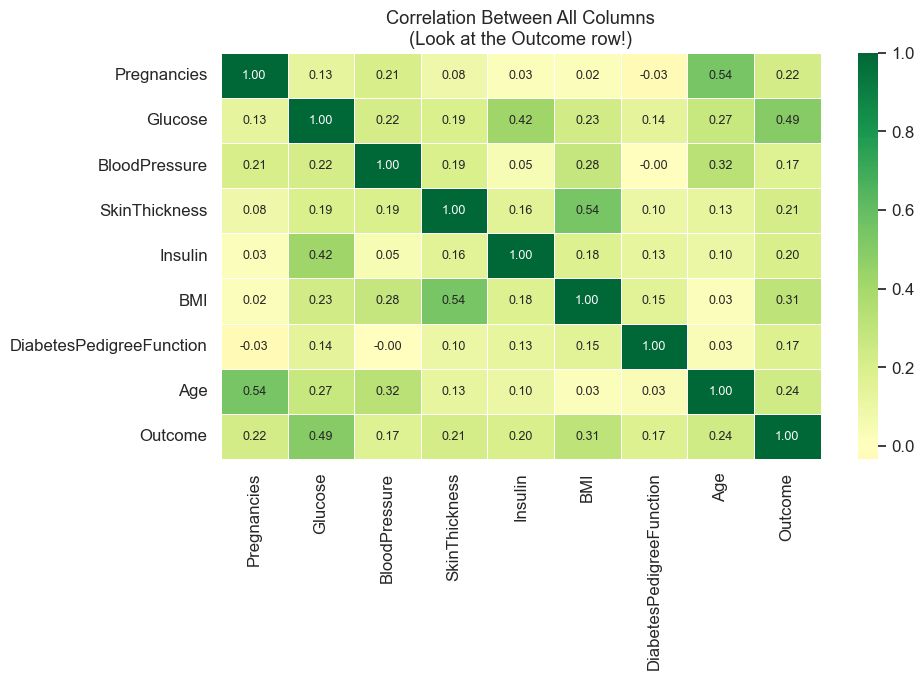


Top features correlated with Outcome:
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [12]:
# Chart 3 — Correlation Heatmap
# Which features are most related to Outcome?
# Look at the Outcome row — darkest green = strongest predictor
plt.figure(figsize=(10, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Between All Columns\n(Look at the Outcome row!)')
plt.tight_layout()
plt.show()
print('\nTop features correlated with Outcome:')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False))

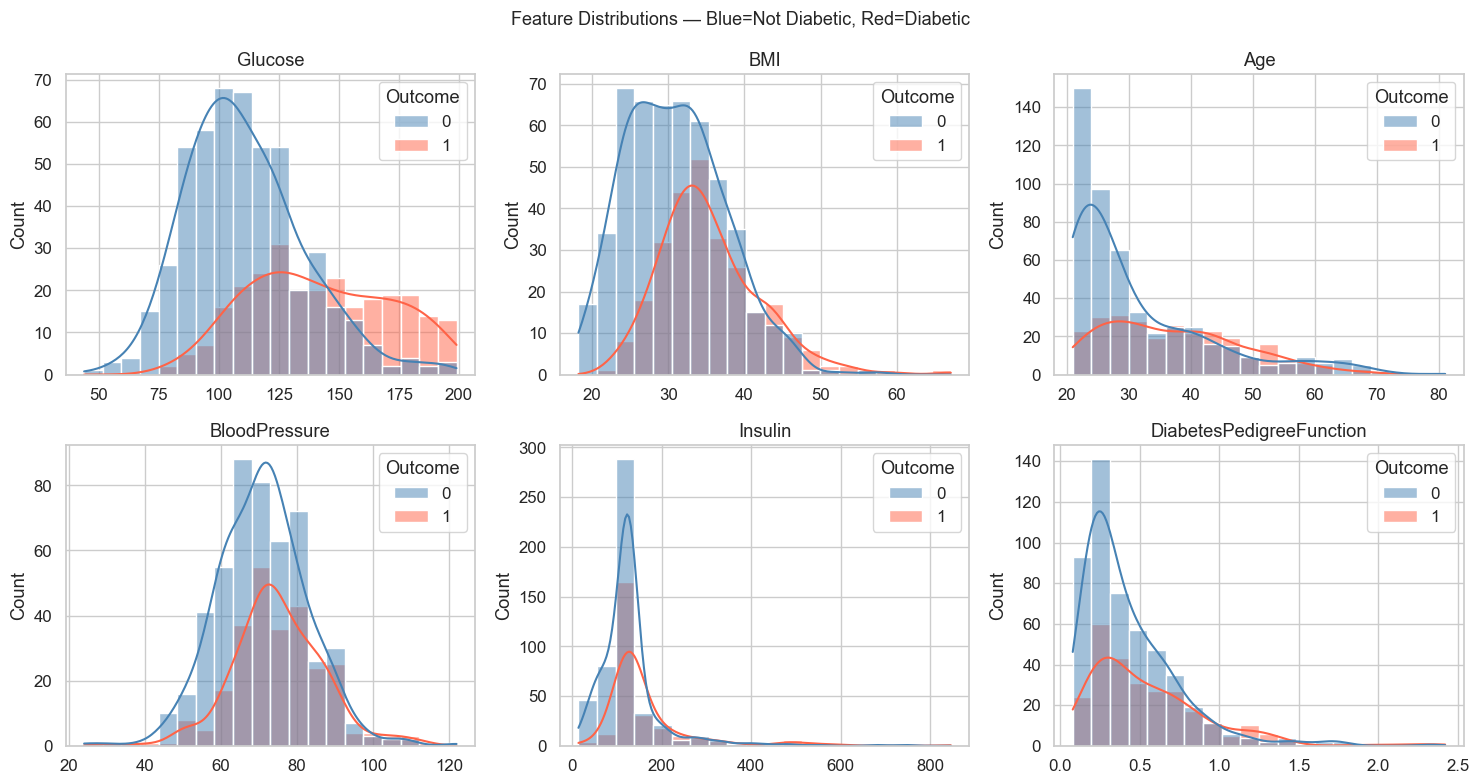

In [13]:
# Chart 4 — Distribution of all features by Outcome
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(features):
    row, c = divmod(i, 3)
    sns.histplot(data=df_clean, x=col, hue='Outcome', bins=20,
                 kde=True, ax=axes[row][c], palette=['steelblue', 'tomato'])
    axes[row][c].set_title(col)
    axes[row][c].set_xlabel('')

plt.suptitle('Feature Distributions — Blue=Not Diabetic, Red=Diabetic', fontsize=13)
plt.tight_layout()
plt.show()

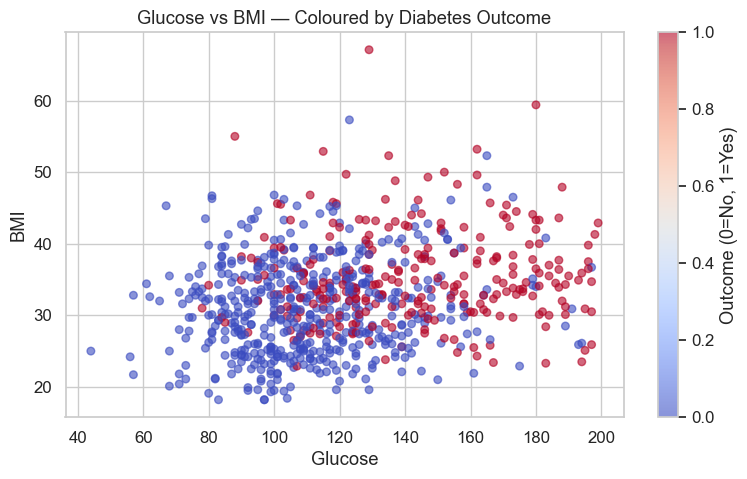

In [14]:
# Chart 5 — Scatter: BMI vs Glucose coloured by Outcome
plt.figure(figsize=(9, 5))
scatter = plt.scatter(df_clean['Glucose'], df_clean['BMI'],
                      c=df_clean['Outcome'], cmap='coolwarm', alpha=0.6, s=30)
plt.colorbar(scatter, label='Outcome (0=No, 1=Yes)')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI — Coloured by Diabetes Outcome')
plt.show()

---
# Step 5 — What is Scikit-learn?
---

## The Most Important ML Library in Python

**Scikit-learn** (imported as `sklearn`) is a free Python library with ready-to-use ML algorithms.

## The Universal Scikit-learn Pattern

Every model — Linear Regression, Random Forest, SVM, KNN — follows the **same 3 steps**:

```
Step 1:  model = ModelName()          ← Create
Step 2:  model.fit(X_train, y_train)  ← Train (learn)
Step 3:  model.predict(X_test)        ← Predict
```

Learn this once — it works for every model you will ever use.

## What Scikit-learn Contains

| Category | Examples |
|----------|----------|
| **Regression** | LinearRegression, Ridge, Lasso |
| **Classification** | LogisticRegression, DecisionTree, SVM, KNN |
| **Preprocessing** | StandardScaler, LabelEncoder, OneHotEncoder |
| **Model Selection** | train_test_split, cross_val_score, GridSearchCV |
| **Metrics** | r2_score, mean_absolute_error, accuracy_score |

---
# Step 6 — Encode Categorical Columns
---

## Good News for This Dataset!

The Diabetes dataset has **NO categorical (text) columns** — all columns are already numbers.

This is why it is a great beginner dataset. No encoding needed!

We still do this step to:
1. Separate Features (X) and Target (y)
2. Confirm no encoding is required

In [15]:
# Make a copy for ML preparation
df_ml = df_clean.copy()

# Check for text columns
text_cols = df_ml.select_dtypes(include='object').columns.tolist()
print('Text columns needing encoding:', text_cols if text_cols else 'None ✅ — all columns are already numeric!')

Text columns needing encoding: None ✅ — all columns are already numeric!


In [16]:
# Separate Features (X) and Target (y)
# X = all health indicator columns (inputs)
# y = Outcome column (what we predict)

X = df_ml.drop(columns=['Outcome'])   # 8 health features
y = df_ml['Outcome']                  # 0 or 1

print(f'X (features) shape : {X.shape}  → {X.shape[1]} features per patient')
print(f'y (target)   shape : {y.shape}  → one outcome per patient')
print(f'\nFeature columns: {X.columns.tolist()}')
print(f'Target column  : Outcome (0=Not Diabetic, 1=Diabetic)')

X (features) shape : (768, 8)  → 8 features per patient
y (target)   shape : (768,)  → one outcome per patient

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target column  : Outcome (0=Not Diabetic, 1=Diabetic)


---
# Step 7 — Feature Scaling
---

## Why Scale Features?

Different columns have very different value ranges:

```
Insulin       →  14  to  846     (range of 832)
Glucose       →  44  to  199     (range of 155)
Age           →  21  to  81      (range of 60)
BMI           →  18  to  67      (range of 49)
Pregnancies   →  0   to  17      (range of 17)
```

Without scaling, the model might wrongly think Insulin (0-846) matters more than Pregnancies (0-17) just because its numbers are bigger.

**StandardScaler** brings everything to Mean=0, Std=1 so all features are judged fairly.

## IMPORTANT: Split BEFORE Scaling — Avoid Data Leakage!

---
# Step 8 — Train-Test Split
---

## Why Split?

```
768 patients
     ↓
train_test_split(test_size=0.2)
     ↓
Training: 614 patients → model learns
Test:     154 patients → we evaluate
```

Test data = patients the model has NEVER seen. This is how we measure real performance.

In [17]:
# Split FIRST — before any scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Total   : {len(X)} patients')
print(f'Train   : {len(X_train)}  (80%)')
print(f'Test    : {len(X_test)}   (20%)')

Total   : 768 patients
Train   : 614  (80%)
Test    : 154   (20%)


In [18]:
# Now scale — AFTER splitting
scaler = StandardScaler()

# fit_transform on TRAINING: learn mean/std, then apply
X_train_scaled = scaler.fit_transform(X_train)

# transform on TEST: apply the SAME mean/std (NO fit here — avoids data leakage!)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('✅ Scaling done!')
print(f'Glucose mean after scaling: {X_train_scaled["Glucose"].mean():.4f}  (should be ~0.0)')
print(f'Glucose std  after scaling: {X_train_scaled["Glucose"].std():.4f}   (should be ~1.0)')

✅ Scaling done!
Glucose mean after scaling: 0.0000  (should be ~0.0)
Glucose std  after scaling: 1.0008   (should be ~1.0)


---
# Step 9 — What is Linear Regression?
---

## The Equation

```
Outcome = (w1 × Glucose)
        + (w2 × BMI)
        + (w3 × Age)
        + (w4 × Insulin)
        + (w5 × BloodPressure)
        + (w6 × SkinThickness)
        + (w7 × Pregnancies)
        + (w8 × DiabetesPedigreeFunction)
        + b   (bias)
```

The model learns the best values for w1...w8 from training data.

## ⚠️ Note on Using Linear Regression for This Dataset

The `Outcome` is 0 or 1 (binary), which technically suits **Logistic Regression** (Classification).
However, we are using **Linear Regression** as assigned — it will still produce predictions
that we can round to 0 or 1 to measure how well it separates the two classes.
This is a valid learning exercise for understanding the complete ML workflow.

---
# Step 10 — Train the Model
---

In [19]:
# Step 1 — Create the model
model = LinearRegression()
print('Model created — not trained yet')

Model created — not trained yet


In [20]:
# Step 2 — Train the model (.fit is where ALL learning happens)
model.fit(X_train_scaled, y_train)
print('✅ Model trained!')

# See what weights the model learned for each feature
coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print(f'\nBias (intercept): {model.intercept_:.4f}')
print('\nFeature Weights (larger = more influence on prediction):')
print(coeff_df.to_string(index=False))

✅ Model trained!

Bias (intercept): 0.3469

Feature Weights (larger = more influence on prediction):
                 Feature  Coefficient
                 Glucose       0.1923
                     BMI       0.1079
                     Age       0.0669
             Pregnancies       0.0369
DiabetesPedigreeFunction       0.0302
           SkinThickness       0.0067
                 Insulin      -0.0205
           BloodPressure      -0.0222


In [21]:
# Step 3 — Make predictions on TEST set
# These are 154 patients the model has NEVER seen
y_pred = model.predict(X_test_scaled)

# Clip predictions to 0-1 range
y_pred_clipped = np.clip(y_pred, 0, 1)

# Round to 0 or 1 for classification comparison
y_pred_rounded = np.round(y_pred_clipped).astype(int)

print('✅ Predictions made!')
print(f'\nFirst 5 actual outcomes   : {y_test.values[:5]}')
print(f'First 5 raw predictions   : {y_pred[:5].round(3)}')
print(f'First 5 rounded predictions: {y_pred_rounded[:5]}')

✅ Predictions made!

First 5 actual outcomes   : [0 0 0 0 0]
First 5 raw predictions   : [0.319 0.22  0.137 0.21  0.483]
First 5 rounded predictions: [0 0 0 0 0]


---
# Step 11 — Evaluate the Model
---

We use standard regression metrics AND accuracy to evaluate performance:

| Metric | Meaning |
|--------|---------|
| **MAE** | Average prediction error |
| **MSE** | Mean squared error (penalises big errors more) |
| **RMSE** | Square root of MSE (same units as target) |
| **R² Score** | How much variance the model explains (1.0 = perfect) |
| **Accuracy** | % of patients correctly classified as diabetic/not |

In [22]:
# Calculate all metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
accuracy = (y_pred_rounded == y_test.values).mean() * 100

print('=' * 40)
print('       MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  MAE      : {mae:.4f}')
print(f'  MSE      : {mse:.4f}')
print(f'  RMSE     : {rmse:.4f}')
print(f'  R² Score : {r2:.4f}')
print(f'  Accuracy : {accuracy:.2f}%')
print('=' * 40)
print(f'\n✅ The model correctly classified {accuracy:.1f}% of patients')

       MODEL EVALUATION RESULTS
  MAE      : 0.3353
  MSE      : 0.1647
  RMSE     : 0.4059
  R² Score : 0.2825
  Accuracy : 77.27%

✅ The model correctly classified 77.3% of patients


---
# Step 12 — Visualise Predictions
---

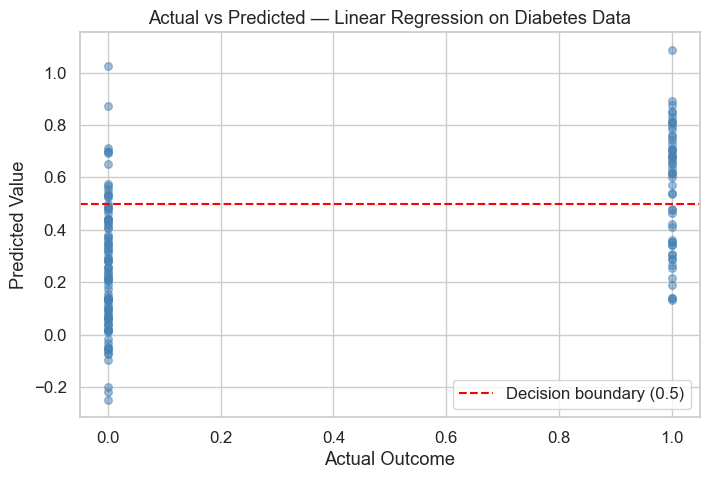

In [23]:
# Chart 1 — Actual vs Predicted scatter
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=30)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
plt.xlabel('Actual Outcome')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted — Linear Regression on Diabetes Data')
plt.legend()
plt.show()

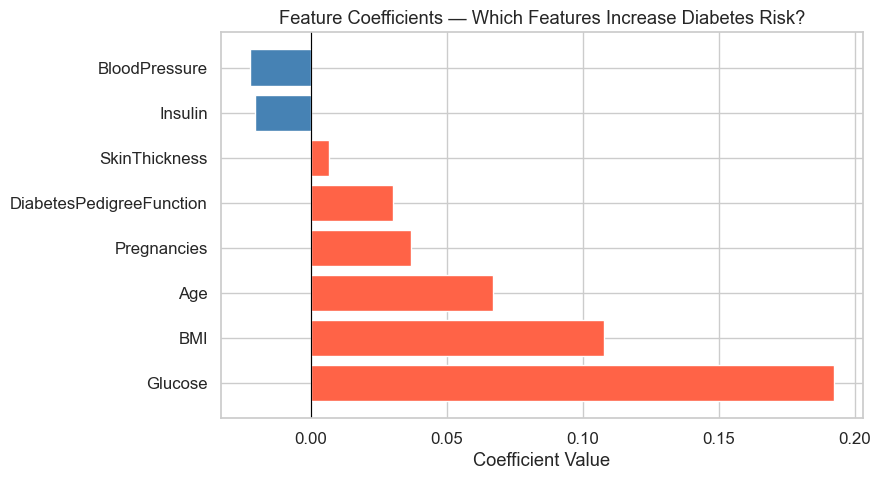

Red bars = increases diabetes probability
Blue bars = decreases diabetes probability


In [24]:
# Chart 2 — Feature Importance (Coefficients)
plt.figure(figsize=(9, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coeff_df['Coefficient']]
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Which Features Increase Diabetes Risk?')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()
print('Red bars = increases diabetes probability')
print('Blue bars = decreases diabetes probability')

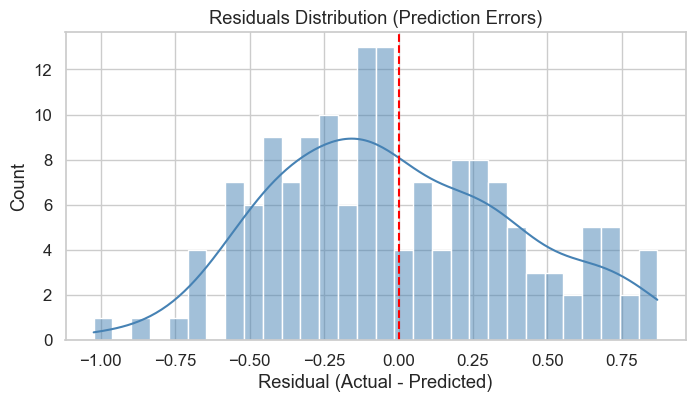

A bell curve centered at 0 = model errors are random and unbiased ✅


In [25]:
# Chart 3 — Residuals (Prediction Errors)
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Residuals Distribution (Prediction Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()
print('A bell curve centered at 0 = model errors are random and unbiased ✅')

---
# Step 13 — Predict New Patients
---

The real use case: a doctor inputs a new patient's readings and gets a diabetes prediction.

In [26]:
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]

new_patients = pd.DataFrame({
    'Pregnancies'              : [6,   1,   2],
    'Glucose'                  : [148, 85,  120],
    'BloodPressure'            : [72,  66,  70],
    'SkinThickness'            : [35,  29,  25],
    'Insulin'                  : [0,   0,   100],
    'BMI'                      : [33.6, 26.6, 28.0],
    'DiabetesPedigreeFunction' : [0.627, 0.351, 0.200],
    'Age'                      : [50,  31,  25]
})

# Scale using the SAME scaler fitted on training data
new_patients_scaled = scaler.transform(new_patients)

# Predict
new_predictions = model.predict(new_patients_scaled)
new_predictions_clipped = np.clip(new_predictions, 0, 1)
new_predictions_rounded = np.round(new_predictions_clipped).astype(int)

for i in range(len(new_patients)):
    result = 'DIABETIC 🔴' if new_predictions_rounded[i] == 1 else 'NOT DIABETIC 🟢'
    print(f'Patient {i+1}: Score = {new_predictions_clipped[i]:.3f} → {result}')

Patient 1: Score = 0.711 → DIABETIC 🔴
Patient 2: Score = 0.014 → NOT DIABETIC 🟢
Patient 3: Score = 0.189 → NOT DIABETIC 🟢


---
# Step 14 — Summary + Exercises
---

## ✅ What We Did

| Step | What We Did |
|------|-------------|
| Load | Loaded 768 patient records from CSV |
| Explore | Found zeros hiding as missing values in 5 medical columns |
| Clean | Replaced zeros with column medians |
| Visualise | Heatmap, distributions, boxplots by outcome |
| Encode | No encoding needed — all numeric columns |
| Scale | StandardScaler on training data only |
| Split | 80% train / 20% test |
| Train | LinearRegression().fit() |
| Evaluate | MAE, MSE, RMSE, R², Accuracy |
| Predict | New patient predictions |



In [27]:
import joblib

# ── Save ─────────────────────────────────────────────────────
save_data = {
    'model'  : model,
    'scaler' : scaler,
    'columns': list(X.columns)
}

joblib.dump(save_data, 'diabetes_model.joblib')

print('Model saved!')

Model saved!


-----------
#load the model
-----------

In [28]:
saved=joblib.load('diabetes_model.joblib')
model= saved['model']
scaler=saved['scaler']
columns=saved['columns']
print('Model loaded successfully!')


Model loaded successfully!
